## This Notebook trains a Neural Network for Galaxy-Matter-Powerspektra Predictions

In [32]:
import g3lhalo
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np
import random
from pyDOE import lhs
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.activations import gelu
from tensorflow.keras.losses import MeanSquaredError
import tensorflow_addons as tfa
import optuna
from tensorflow.keras.layers import LeakyReLU, ELU

# Für spezielle Aktivierungen wie Swish, GELU
try:
    from tensorflow.keras.activations import swish, gelu
except ImportError:
    # Alternative falls alte TensorFlow-Version
    def swish(x): return x * tf.nn.sigmoid(x)
    def gelu(x): return 0.5 * x * (1.0 + tf.tanh(tf.sqrt(2.0 / tf.constant(np.pi)) * (x + 0.044715 * tf.pow(x, 3))))

# Für AdamW und RAdam Optimizer:
try:
    from tensorflow_addons.optimizers import AdamW, RectifiedAdam
except ImportError:
    # Falls nicht installiert:
    # pip install tensorflow-addons
    print("Installiere tensorflow-addons mit: pip install tensorflow-addons")

In [33]:
#%pip install tensorflow
#%pip install pyDOE
#%pip install pandas
#%pip install seaborn
#%pip install tensorflow-addons
#%pip install filelock
#%pip install pyccl

In [34]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

using cpu device 



In [35]:
# setting the seed for reproducibility
np.random.seed(9721)
tf.random.set_seed(9721)

In [36]:
# Gesamtanzahl der Samples
N_total = 10000

# Verhältnis der Validierungsdaten
f_val = 0.15
f_train = 1 - f_val

# Anzahl an Trainings- und Validierungssamples
N_train = int(f_train * N_total)
N_val = N_total - N_train  # Rest wird Validation

# Indizes mischen
indices = np.arange(N_total)
np.random.shuffle(indices)

# Aufteilen
training_indices = indices[:N_train]
validation_indices = indices[N_train:]

print(f"Train: {len(training_indices)} samples")
print(f"Validation: {len(validation_indices)} samples")


Train: 8500 samples
Validation: 1500 samples


/tmp/ipykernel_3177183/1822485009.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


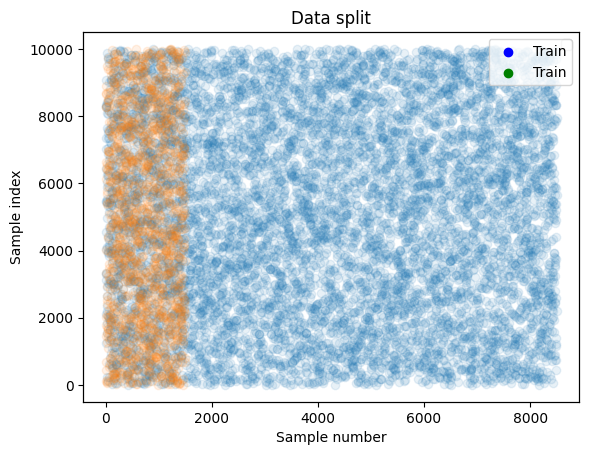

In [37]:
# Plot of test_indices and train_indices
fig, axes=plt.subplots()

plt.scatter(np.arange(N_train), training_indices, alpha=0.1)
plt.scatter(np.arange(N_val), validation_indices, alpha=0.1)

plt.title('Data split')

plt.xlabel('Sample number')
plt.ylabel('Sample index')

ax2=axes.twinx()
ax2.scatter(np.NaN, np.NaN, label='Train', color='blue')
ax2.scatter(np.NaN, np.NaN, label='Train', color='green')
ax2.set_yticks([])

axes.legend()
ax2.legend(loc='upper right')
#plt.savefig('../Plots/DataSplit.png', dpi=600)


## Read in generated Targets

In [38]:
# Create directory to save the generated data
data_dir = "../Data/"
os.makedirs(data_dir, exist_ok=True)

In [39]:
# Specifying the storage location of the data
data_dir = "../Data/"

# File path to the saved JSON file
data_fn = f"{data_dir}GeneratedData_10000_2025-05-20_12-41-13_alpha0_01.json"
# read in data
with open(data_fn, "r") as json_file:
    data_samples = json.load(json_file)

# Define keys needed for Galaxie-Matter
target_keys = [ 
    'Pk_sl_1h', 'Pk_sl_2h', 'Pk_sl'
]

# Create numpy arrays for each of the Pk_* columns
targets_array = {key: np.array([sample[key] for sample in data_samples]) for key in target_keys}


# Logarithmic transformation of the data
def log_transform(targets_array):
    return {key: np.log(data) for key, data in targets_array.items()}

# Calculate logarithms of the data
log_transformed_data = log_transform(targets_array)

# Split the data into training, test and validation sets
training_targets = {}
validation_targets = {}


# Convert dictionaries to NumPy arrays
training_targets['modes'] = np.array([data[:][training_indices] for data in targets_array.values()])
training_targets['targets'] = np.array([data[:][training_indices] for data in log_transformed_data.values()])

validation_targets['modes'] = np.array([data[:][validation_indices] for data in targets_array.values()])
validation_targets['targets'] = np.array([data[:][validation_indices] for data in log_transformed_data.values()])

# Define keys needed for linear term
lin_keys = [ 
    'Pk_lin'
]

# Create numpy arrays for linear term
lin_array = {key: np.array([sample[key] for sample in data_samples]) for key in lin_keys}

# Split the linear term data into training, test and validation sets
lin_training_targets = {}
lin_validation_targets = {}

# Convert dictionaries to NumPy arrays
lin_training_targets['modes'] = np.array([data[:][training_indices] for data in lin_array.values()])
lin_training_targets['targets'] = np.array([data[:][training_indices] for data in log_transformed_data.values()])

lin_validation_targets['modes'] = np.array([data[:][validation_indices] for data in lin_array.values()])
lin_validation_targets['targets'] = np.array([data[:][validation_indices] for data in log_transformed_data.values()])


In [40]:
print('number of training targets:', len(training_targets['modes'][:][0]), '. Should be', N_train)
print('number of validation targets:', len(validation_targets['modes'][:][0]), '. Should be', N_val)

number of training targets: 8500 . Should be 8500
number of validation targets: 1500 . Should be 1500


In [41]:
N_modes=len(training_targets['modes'])
print(f"Shape of training targets: {training_targets['targets'].shape}. Should be ({N_modes}, {N_train}, 50)")
print(f"Shape of validation targets: {validation_targets['targets'].shape}. Should be ({N_modes}, {N_val}, 50)")

Shape of training targets: (3, 8500, 50). Should be (3, 8500, 50)
Shape of validation targets: (3, 1500, 50). Should be (3, 1500, 50)


## Read in lin

In [42]:
#print('number of training targets:', len(lin_training_targets['modes'][:][0]), '. Should be', N_train)
#print('number of validation targets:', len(lin_validation_targets['modes'][:][0]), '. Should be', N_val)

#print('number of test targets:', len(lin_testing_targets['modes'][:][0]), '. Should be', N_test)

In [43]:
N_modes=len(lin_training_targets['modes'])
#print(f"Shape of training targets: {lin_training_targets['modes'].shape}. Should be ({N_modes}, {N_train}, 50)")
#print(f"Shape of testing targets: {lin_testing_targets['modes'].shape}. Should be ({N_modes}, {N_test}, 50)")
#print(f"Shape of validation targets: {lin_validation_targets['modes'].shape}. Should be ({N_modes}, {N_val}, 50)")

## Read in related features

In [44]:
para_fn = f"{data_dir}Parameter_10000_2025-05-20_12-41-13_alpha0_01.json"
# Read in
with open(para_fn, "r") as json_file:
    samples = json.load(json_file)

# Create numpy arrays for each of the parameter columns
feature_keys = ['Om_c', 'Om_b', 'h', 'sigma_8', 'n_s', 'alpha', 'sigma', 'Mth', 'Mprime', 'beta']

# List of arrays for each parameter
feature_array = {key: np.array([sample[key] for sample in samples]) for key in feature_keys}

# Split features into training, validation and test data
training_features = {key: feature[training_indices] for key, feature in feature_array.items()}
validation_features = {key: feature[validation_indices] for key, feature in feature_array.items()}

training_features = np.array(list(zip(*training_features.values())))
validation_features = np.array(list(zip(*validation_features.values())))


In [45]:
log_indices = [7, 8]  # Ersetze mit deinen echten Indizes

training_features[:, log_indices] = np.log10(training_features[:, log_indices])
validation_features[:, log_indices] = np.log10(validation_features[:, log_indices])

print("input min/max:", training_features.min(), training_features.max())

input min/max: 5.841504783488005e-07 16.999995314217603


In [46]:
print('number of training features:', len(training_features), '. Should be', N_train)
print('number of validation features:', len(validation_features), '. Should be', N_val)

number of training features: 8500 . Should be 8500
number of validation features: 1500 . Should be 1500


## Cross check
Now, for a cross check we plot the mean of the training, testing and validation data sets. These should all look roughly the same, otherwise we have selected strange test and validation sets.

In [47]:
mean_training_targets = []
std_training_targets = []

mean_validation_targets = []
std_validation_targets = []

# Calculate mean and standard deviation for training targets
for i in range(len(training_targets['modes'])):  # for all 3-Halo terms
    halo_data = np.array(training_targets['targets'][i])
    
    mean = np.mean(halo_data, axis=0)  # mean over complete training sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete training sample for every k-value
    
    mean_training_targets.append(mean)
    std_training_targets.append(std)

# Calculate mean and standard deviation for validation targets
for i in range(len(validation_targets['modes'])):  # for all 3-Halo terms
    halo_data = np.array(validation_targets['targets'][i])

    mean = np.mean(halo_data, axis=0)  # mean over complete validation sample for every k-value
    std = np.std(halo_data, axis=0)    # standard deviation over complete validation sample for every k-value

    mean_validation_targets.append(mean)
    std_validation_targets.append(std)




In [48]:
mean_training_features = []
std_training_features = []

mean_validation_features = []
std_validation_features = []


# Calculate mean and standard deviation for training features
for i in range(len(training_features[0])):  # for all 3-Halo terms
    feature_parameter = np.array(training_features[:,i])
    
    mean = np.mean(feature_parameter, axis=0)  # mean over complete training sample for every k-value
    std = np.std(feature_parameter, axis=0)    # standard deviation over complete training sample for every k-value
    
    mean_training_features.append(mean)
    std_training_features.append(std)

# Calculate mean and standard deviation for validation features
for i in range(len(validation_features[0])):  # for all 3-Halo terms
    feature_parameter = np.array(validation_features[:,i])

    mean = np.mean(feature_parameter, axis=0)  # mean over complete validation sample for every k-value
    std = np.std(feature_parameter, axis=0)    # standard deviation over complete validation sample for every k-value

    mean_validation_features.append(mean)
    std_validation_features.append(std)


feature_keys = ['Om_c', 'Om_b', 'h', 'sigma_8', 'n_s', 'alpha', 'sigma', 'Mth', 'Mprime', 'beta']

## Renaming

In [49]:
# features
train_targets=training_targets['targets']
val_targets=validation_targets['targets']

## Rescaling
We are rescaling the features by the mean and standard deviation of the training features. Then, they are all scattering by 1 and have a mean value of 0.


In [50]:
# Calculate mean and standard deviation **only from the training data**
target_processing_vectors = {
    'mean': np.mean(train_targets, axis=1, keepdims=True),
    'sigma': np.std(train_targets, axis=1, keepdims=True)
}

# Ensure that no division by zero occurs
target_processing_vectors['sigma'][target_processing_vectors['sigma'] == 0] = 1  

# Preprocessing function
def preprocessing(targets, processing_vectors):
    return (targets - processing_vectors['mean']) / processing_vectors['sigma']

# Postprocessing function
def postprocessing(targets, processing_vectors):
    return targets * processing_vectors['sigma'] + processing_vectors['mean']

# Apply preprocessing to all data
train_targets_rescaled = preprocessing(train_targets, target_processing_vectors)
val_targets_rescaled = preprocessing(val_targets, target_processing_vectors)

# JSON-compatible storage of the processing vectors
#serializable_processing_vectors = {key: value.tolist() for key, value in processing_vectors.items()}
#processing_out="../Emulators/NM_processing_vectors.json"
#with open(processing_out, "w") as json_file:
#    json.dump(serializable_processing_vectors, json_file)

# Check shapes after the transformation
print("Train Rescaled Shape:", train_targets_rescaled.shape)
print("Val Rescaled Shape:", val_targets_rescaled.shape)



Train Rescaled Shape: (3, 8500, 50)
Val Rescaled Shape: (3, 1500, 50)


In [51]:
mean_training_targets_rescaled = []
std_training_targets_rescaled = []

mean_validation_targets_rescaled = []
std_validation_targets_rescaled = []

# Calculate mean and standard deviation for rescaled training targets
for i in range(len(train_targets_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(train_targets_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled training sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled training sample for every k-value

    mean_training_targets_rescaled.append(mean)
    std_training_targets_rescaled.append(std)

# Calculate mean and standard deviation for rescaled validation targets
for i in range(len(val_targets_rescaled)):  # for all 3-Halo terms
    halo_data_rescaled = np.array(val_targets_rescaled[i])

    mean = np.mean(halo_data_rescaled, axis=0)  # mean over complete rescaled validation sample for every k-value
    std = np.std(halo_data_rescaled, axis=0)    # standard deviation over complete rescaled validation sample for every k-value

    mean_validation_targets_rescaled.append(mean)
    std_validation_targets_rescaled.append(std)


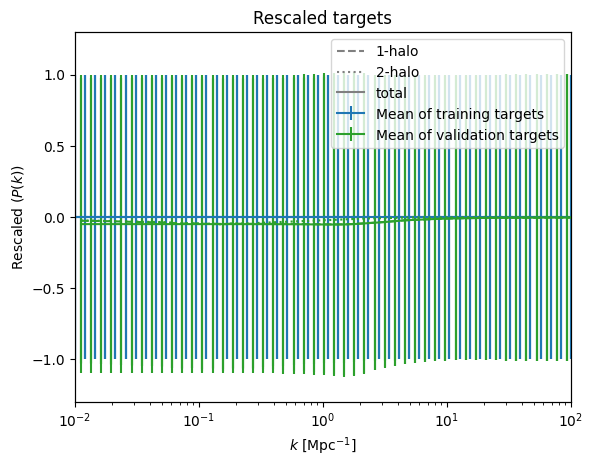

In [52]:
ks = np.geomspace(1e-2, 1e2)
fig, axes=plt.subplots()
#axes.loglog(ks, Pk_lin, color='k', label='linear')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'Rescaled $(P(k))$')
plt.title('Rescaled targets')

ax2=axes.twinx()
ax2.plot(np.NaN, np.NaN, ls='--', label='1-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls=':', label='2-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls='-', label='total', color='grey')
ax2.set_yticks([])



plt.errorbar(ks,mean_training_targets_rescaled[0], 
             yerr=std_training_targets_rescaled[0], color='C0', label='Mean of training targets')
plt.errorbar(ks,mean_training_targets_rescaled[1], ls=':', 
             yerr=std_training_targets_rescaled[1], color='C0')
plt.errorbar(ks,mean_training_targets_rescaled[2], ls='--', 
             yerr=std_training_targets_rescaled[2], color='C0')

plt.errorbar(ks*1.12,mean_validation_targets_rescaled[0], 
             yerr=std_validation_targets_rescaled[0], color='C2', label='Mean of validation targets')
plt.errorbar(ks*1.12,mean_validation_targets_rescaled[1], ls=':', 
             yerr=std_validation_targets_rescaled[1], color='C2')
plt.errorbar(ks*1.12,mean_validation_targets_rescaled[2], ls='--', 
             yerr=std_validation_targets_rescaled[2], color='C2')

axes.set_ylim(-1.3, 1.3)
plt.xlim(1e-2,100)
plt.ylim(-1.3,1.3)
plt.xscale('log')
plt.legend()
#plt.savefig('../Plots/RescaledTargets.png', dpi=600)

In [53]:
# Calculate mean and standard deviation **only from the training data**
feature_processing_vectors = {
    'mean': np.array(mean_training_features).reshape(1, -1),
    'sigma': np.array(std_training_features).reshape(1, -1)
}


# Ensure that no division by zero occurs
feature_processing_vectors['sigma'][feature_processing_vectors['sigma'] == 0] = 1  

# Preprocessing function
def preprocessing(features, processing_vectors):
    return (features - processing_vectors['mean']) / processing_vectors['sigma']

# Postprocessing function
def postprocessing(features, processing_vectors):
    return features * processing_vectors['sigma'] + processing_vectors['mean']

# Apply preprocessing to all data
train_features_rescaled = preprocessing(training_features, feature_processing_vectors)
val_features_rescaled = preprocessing(validation_features, feature_processing_vectors)

# JSON-compatible storage of the processing vectors
#serializable_processing_vectors = {key: value.tolist() for key, value in processing_vectors.items()}
#processing_out="../Emulators/NM_processing_vectors.json"
#with open(processing_out, "w") as json_file:
#    json.dump(serializable_processing_vectors, json_file)

# Check shapes after the transformation
print("Train Rescaled Shape:", train_features_rescaled.shape)
print("Val Rescaled Shape:", val_features_rescaled.shape)



Train Rescaled Shape: (8500, 10)
Val Rescaled Shape: (1500, 10)


In [54]:


mean_training_features_rescaled = []
std_training_features_rescaled = []

mean_validation_features_rescaled = []
std_validation_features_rescaled = []


# Calculate mean and standard deviation for training features
for i in range(len(train_features_rescaled[0])):  # for all 3-Halo terms
    feature_parameter = np.array(train_features_rescaled[:,i])
    
    mean = np.mean(feature_parameter, axis=0)  # mean over complete training sample for every k-value
    std = np.std(feature_parameter, axis=0)    # standard deviation over complete training sample for every k-value
    mean_training_features_rescaled.append(mean)
    std_training_features_rescaled.append(std)

# Calculate mean and standard deviation for validation features
for i in range(len(val_features_rescaled[0])):  # for all 3-Halo terms
    feature_parameter = np.array(val_features_rescaled[:,i])

    mean = np.mean(feature_parameter, axis=0)  # mean over complete validation sample for every k-value
    std = np.std(feature_parameter, axis=0)    # standard deviation over complete validation sample for every k-value

    mean_validation_features_rescaled.append(mean)
    std_validation_features_rescaled.append(std)


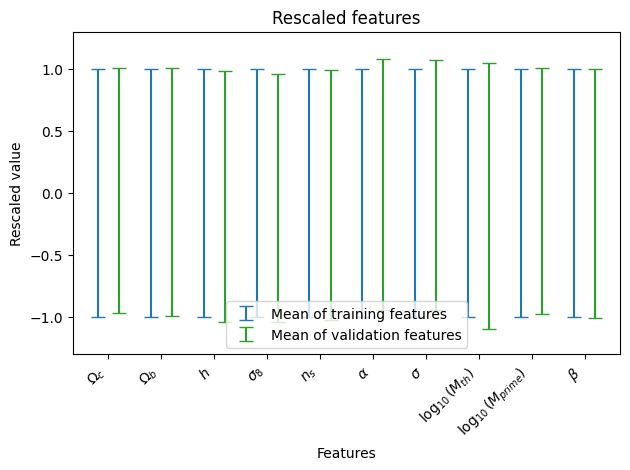

In [55]:
x_pos = np.arange(len(feature_keys))  # numerische Positionen für die x-Werte
offset = 0.2  # Abstand, um die Features ein bisschen zu verschieben

fig, axes = plt.subplots()

axes.set_xlabel('Features')
axes.set_ylabel('Rescaled value')
axes.set_title('Rescaled features')

# Optional: Y-Achse logarithmisch
axes.set_xscale('linear')
axes.set_yscale('linear')

# Training Features
axes.errorbar(x_pos - offset, mean_training_features_rescaled, 
              yerr=std_training_features_rescaled, ls='none', 
              color='C0', label='Mean of training features', capsize=5)

# Validation Features
axes.errorbar(x_pos + offset, mean_validation_features_rescaled, 
              yerr=std_validation_features_rescaled, ls='none', 
              color='C2', label='Mean of validation features', capsize=5)


# Setze die Original-Feature-Namen als x-Achsen-Beschriftung
axes.set_xticks(x_pos)
axes.set_xticklabels(['$\\Omega_c$', '$\\Omega_b$', '$h$', '$\\sigma_8$', '$n_s$', '$\\alpha$', '$\\sigma$', '$\log_{10}(M_{th})$', '$\log_{10}(M_{prime})$', '$\\beta$' ])
plt.xticks(rotation=45, ha='right')


axes.set_ylim(-1.3, 1.3)
plt.ylim(-1.3,1.3)
# Legende
plt.legend()

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Justiere den unteren Rand des Plots
#plt.savefig('../Plots/RescaledFeatures.png', dpi=600)
plt.show()

## NN training

### Define Model

Define Neural Network with following structure

### Set training hyperparameters
We set some hyperparameters: How many features are processed in one step (batch_size), how fast the gradient descent should happen (learning_Rate), after how many steps without improvement the learning should stop (patience_values) and what is the maximal number of learning steps (max_epochs).

We also set where to save the emulator

In [56]:
#restructuring of the arrays
train_targets_rescaled = np.transpose(train_targets_rescaled, (1, 0, 2))



In [57]:
patience_values=[100, 100, 1000]
max_epochs=[1000, 1000, 10000]
learning_rate = 0.0018012867246411806/1000
batch_size = 924 

In [58]:
#load
timestamp = '2025-05-17_20-32-45' 

model = keras.models.load_model(
    f'../NN_builds/NN_{timestamp}.keras',
    compile=False
)
model.compile(optimizer=RectifiedAdam(), loss='mse', metrics=["mae"])


# Layer-Infos extrahieren
n_layers = len(model.layers)
n_units = [layer.get_config().get('units') for layer in model.layers if 'units' in layer.get_config()]
activations = [layer.get_config().get('activation') for layer in model.layers if 'activation' in layer.get_config()]
activation = activations[0] if activations else "unknown"

# Optimizer-Infos extrahieren
optimizer_choice = type(model.optimizer).__name__ if model.optimizer else "uncompiled"

all_training_loss=[]
all_validation_loss=[]


In [59]:
print(f"Training model with params: layers={n_layers}, units={n_units}, activation={activation}, optimizer={optimizer_choice}, lr={learning_rate}")

for i in range(len(max_epochs)):
    earlystop = keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience_values[i], restore_best_weights=True, verbose=0
        )  
    history = model.fit(
        train_features_rescaled,
        train_targets_rescaled.reshape((N_train, 150)),
        epochs=max_epochs[i],
        verbose=0,
        validation_data=(val_features_rescaled, val_targets_rescaled.reshape((N_val, 150))),
        callbacks=[earlystop],
        batch_size=batch_size
    )

    all_training_loss.extend(history.history['loss'])
    all_validation_loss.extend(history.history['val_loss'])



    # Learning Rate um Faktor 10 reduzieren
    tf.keras.backend.set_value(model.optimizer.learning_rate, learning_rate / (10 ** i))
    print(f"Finish Trainingstep {i+1} of {len(max_epochs)} with lr={learning_rate} and {max_epochs[i]} epochs")




# loss auswerten
loss, train_mae = model.evaluate(train_features_rescaled, train_targets_rescaled.reshape((N_train, 150)), verbose=0)
val_loss, val_mae = model.evaluate(val_features_rescaled, val_targets_rescaled.reshape((N_val, 150)), verbose=0)

# Logfile schreiben
with open("training_runs_fixed.txt", "a") as f:
    f.write(f"{timestamp} loss={loss:.6f}, validation loss={val_loss:.6f}, train_mae={train_mae:.6f}, val_mae={val_mae:.6f}, ")
    f.write(f"params={{'n_layers': {n_layers}, 'n_units': {n_units}, 'activation': '{activation}', 'optimizer': '{optimizer_choice}', 'lr': {learning_rate}}}\n")

Training model with params: layers=6, units=[70, 70, 70, 70, 70, 150], activation=sigmoid, optimizer=RectifiedAdam, lr=1.8012867246411806e-06
Finish Trainingstep 1 of 3 with lr=1.8012867246411806e-06 and 1000 epochs
Finish Trainingstep 2 of 3 with lr=1.8012867246411806e-06 and 1000 epochs
Finish Trainingstep 3 of 3 with lr=1.8012867246411806e-06 and 10000 epochs


In [60]:
training_history = {
    'loss': all_training_loss,
    'val_loss': all_validation_loss
}

In [61]:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
#save
model.save(f'../NN_builds_Optimized/NN_{timestamp}.keras')

with open(f'../Traininghist/full_training_history_{timestamp}.json', 'w') as f:
    json.dump(training_history, f)
print(timestamp)


2025-05-20_17-26-04
